In [1]:
import os
import gc
import sys
import glob
import numpy as np
import pandas as pd
import netCDF4 as nc
from datetime import datetime, timedelta
from matplotlib.cm import get_cmap
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib import colors
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import multiprocessing as mp

In [2]:
# To use PLUMBER2_GPP_common_utils, change directory to where it exists
os.chdir('/srv/ccrc/LandAP/z5218916/script/PLUMBER2/LSM_GPP_PLUMBER2')
from PLUMBER2_GPP_common_utils import *

In [3]:
# Path of PLUMBER 2 dataset
PLUMBER2_path      = "/srv/ccrc/LandAP/z5218916/data/PLUMBER2/"
PLUMBER2_flux_path = "/srv/ccrc/LandAP/z5218916/data/Fluxnet_data/Post-processed_PLUMBER2_outputs/Nc_files/Flux/"
PLUMBER2_met_path  = "/srv/ccrc/LandAP/z5218916/data/Fluxnet_data/Post-processed_PLUMBER2_outputs/Nc_files/Met/"

site_names, IGBP_types, clim_types, model_names = load_default_list()

remove_site        = get_removed_site_names()

models_calc_LAI   = ['ORC2_r6593','ORC2_r6593_CO2','ORC3_r7245_NEE','ORC3_r8120','GFDL','SDGVM','QUINCY','NoahMPv401']
model_LAI_names   = {'ORC2_r6593':'lai','ORC2_r6593_CO2':'lai','ORC3_r7245_NEE':'lai','ORC3_r8120':'lai',
                     'GFDL':'lai', 'SDGVM':'lai','QUINCY':'LAI','NoahMPv401':'LAI'} #

# Calculate remaining sites
set_site_names      = set(site_names)
set_remove_site     = set(remove_site)
remain_sites        = set_site_names - set_remove_site
remain_sites        = list(remain_sites)

In [4]:
model_colors ={0:'red', 1: 'darkorange',2:'orange',3:'gold',4:'yellowgreen',5:'green',6:'mediumseagreen',
               7:'lime',8:'aquamarine',9:'cyan',10:'dodgerblue',11:'blue',12:'darkolivegreen',
               13:'forestgreen',14:'lime',15:'gold', 16:'orange',17:'pink',18:'pink',19:'red',20:'deeppink',
               21:'mediumorchid',22: 'darkviolet',}

IGBP_colors  = set_IGBP_colors()
clim_colors  = set_clim_colors()

<h3 style="color:blue;">Get model list</h3>  

In [6]:
PLUMBER2_path_site = "/srv/ccrc/LandAP/z5218916/script/PLUMBER2/LSM_GPP_PLUMBER2/nc_files/AU-How.nc"
f                  = nc.Dataset(PLUMBER2_path_site, mode='r')
model_list         = f.variables['NEE_models'][:]
model_list         = model_list.tolist()
model_list.append('obs')

In [6]:
time       = nc.num2date(f.variables['CABLE_time'][:],f.variables['CABLE_time'].units,only_use_cftime_datetimes=False,only_use_python_datetimes=True)
ntime      = len(time)
month      = np.zeros(ntime)
hour       = np.zeros(ntime)

for i,t in enumerate(time):
    month[i] = t.month
    hour[i]  = t.hour

<h3 style="color:blue;">Filtering data</h3>  

In [8]:
site_name = 'AU-How'
var_name  = 'GPP'

In [18]:
def get_obs_qc(site_name): 
    
    # Get meteorology input quality
    PLUMBER2_met_path  = "/srv/ccrc/LandAP/z5218916/data/Fluxnet_data/Post-processed_PLUMBER2_outputs/Nc_files/Met/"
    
    file_path          = glob.glob(PLUMBER2_met_path+"/*"+site_name+"*.nc")
    
    with nc.Dataset(file_path[0], 'r') as f:
        var               = pd.DataFrame(f.variables['LWdown_qc'][:,0,0].data, columns=['LWdown_qc'])
        var['LWdown_qc']  = f.variables['LWdown_qc'][:,0,0]
        var['SWdown_qc']  = f.variables['SWdown_qc'][:,0,0]
        var['Precip_qc']  = f.variables['Precip_qc'][:,0,0]
        var['Qair_qc']    = f.variables['Qair_qc'][:,0,0]
        var['Tair_qc']    = f.variables['Tair_qc'][:,0,0]
        var['Wind_qc']    = f.variables['Wind_qc'][:,0,0]
        var['Psurf_qc']   = f.variables['Psurf_qc'][:,0,0]
    
    var       = np.where(var <= 2, 1, np.nan)
    
    return var

In [19]:
var_tmp = get_qc_data(site_name, var_name)

In [20]:
def get_var_qc(var_in, def_val_in, var_name, site_name): 
    
    # Get observed flux quality
    PLUMBER2_flux_path = "/srv/ccrc/LandAP/z5218916/data/Fluxnet_data/Post-processed_PLUMBER2_outputs/Nc_files/Flux/"
    file_path          = glob.glob(PLUMBER2_flux_path+"/*"+site_name+"*.nc")
    
    with nc.Dataset(file_path[0], 'r') as f:
        var['var_qc']  = f.variables[var_name+'_qc'][:,0,0] 
    
    # for col in var.columns:
    #     var[col]       = np.where(var[col] <= 2, 0, 1)

array([[0, 1, 1, ..., 0, 0, 0],
       [0, 1, 1, ..., 0, 0, 0],
       [0, 1, 1, ..., 0, 0, 0],
       ...,
       [0, 1, 0, ..., 0, 0, 0],
       [1, 1, 1, ..., 1, 1, 1],
       [0, 1, 0, ..., 0, 0, 0]])

In [22]:
# plt.scatter(np.arange(len(var_tmp[:,0])),np.sum(var_tmp,axis=1),s=0.1) 
count = np.sum(var_tmp,axis=1)
print(np.sum(count==7))

749


In [23]:
print(np.sum(count==7))

749


In [24]:
print(np.sum(count==6))

14754


In [28]:
print(np.sum(count==2))

48549


In [27]:
print(np.sum(count==1))

119307


In [26]:
print(len(count))

262992


<h3 style="color:blue;">Calculate metrics</h3>  

In [ ]:
def calc_stat(data_in, outlier_method='IQR', min_percentile=0.05, max_percentile=0.95):

    # Delete nan values
    notNan_mask = ~ np.isnan(data_in)
    data_in     = data_in[notNan_mask]

    # calculate statistics
    # Median      = pd.Series(data_in).median()
    print("max(data_in) ", max(data_in))
    print("min(data_in) ", min(data_in))

    Mean        = pd.Series(data_in).mean()
    P25         = pd.Series(data_in).quantile(0.25)
    P75         = pd.Series(data_in).quantile(0.75)
    IQR         = P75-P25
    if outlier_method=='IQR':
        Minimum     = P25 - 1.5*IQR # pd.Series(data_in).quantile(0.05) # # the lowest data point excluding any outliers.
        Maximum     = P75 + 1.5*IQR #pd.Series(data_in).quantile(0.95) # # the largest data point excluding any outliers. Ref: https://www.simplypsychology.org/boxplots.html#:~:text=When%20reviewing%20a%20box%20plot,whiskers%20of%20the%20box%20plot.&text=For%20example%2C%20outside%201.5%20times,Q3%20%2B%201.5%20*%20IQR).
    elif outlier_method=='percentile':
        Minimum     = pd.Series(data_in).quantile(min_percentile) # # the lowest data point excluding any outliers.
        Maximum     = pd.Series(data_in).quantile(max_percentile) # # the largest data point excluding any outliers. Ref: https://www.simplypsychology.org/boxplots.html#:~:text=When%20reviewing%20a%20box%20plot,whiskers%20of%20the%20box%20plot.&text=For%20example%2C%20outside%201.5%20times,Q3%20%2B%201.5%20*%20IQR).


    # print("P25 ", P25)
    # print("P75 ", P75)
    # print("IQR ", IQR)
    # print("Minimum ", Minimum)
    # print("Maximum ", Maximum)

    # return (Median, P25, P75, Minimum, Maximum)
    return (Mean, P25, P75, Minimum, Maximum)


<h3 style="color:blue;">Explore GPP and other variables</h3>  

Guide, explore why model simulate GPP differently, LAI, VPD, SM, CNP, WUE, LUE ???

In [8]:
model_list         = f.variables['NEE_models'][:]
model_list         = f.variables['NEE_models'][:]
model_list         = f.variables['NEE_models'][:]
model_list         = f.variables['NEE_models'][:]
model_list         = f.variables['NEE_models'][:]
model_list         = f.variables['NEE_models'][:]

<h2 style="color:Black;">Annual & seasonal NEE</h2>  

<h3 style="color:blue;">Annual NEE</h3>  

<h4 style="color:green;">Annual mean NEE</h4>  

<h5 style="color:orange;">Check values nan and default values</h5>  

ES-ES2
var_tmp -0.16417818
LAI [0.00000000e+00 5.15365601e-03 3.30760404e-02 3.81306075e-02
 4.39599529e-02 5.56405149e-02 7.73561224e-02 8.62240046e-02
 9.37611908e-02 9.39112753e-02 9.69144031e-02 9.80884209e-02
 1.16519794e-01 1.21537186e-01 1.22119151e-01 1.41142622e-01
 1.45069987e-01 1.66230217e-01 1.72198758e-01 1.82340905e-01
 1.85788751e-01 1.86579064e-01 2.14489624e-01 2.29292318e-01
 2.30798677e-01 2.33252034e-01 2.36112267e-01 2.40506515e-01
 2.52253830e-01 2.55984128e-01 2.65772611e-01 2.93890327e-01
 3.18612993e-01 3.33716273e-01 3.33961755e-01 3.40036482e-01
 3.47934246e-01 3.51664335e-01 3.85015815e-01 3.92945051e-01
 3.94742399e-01 3.97495747e-01 3.98070544e-01 4.01318192e-01
 4.02712673e-01 4.35955852e-01 4.39614564e-01 4.42214757e-01
 4.53126222e-01 4.58932728e-01 4.90543246e-01 4.90922391e-01
 4.94321674e-01 4.98313606e-01 5.23261666e-01 8.97956371e-01
 9.80217636e-01 1.13139176e+00 1.25812161e+00 1.65022993e+00
 1.76616657e+00 1.95622385e+00 2.12168598e+00 2.481215

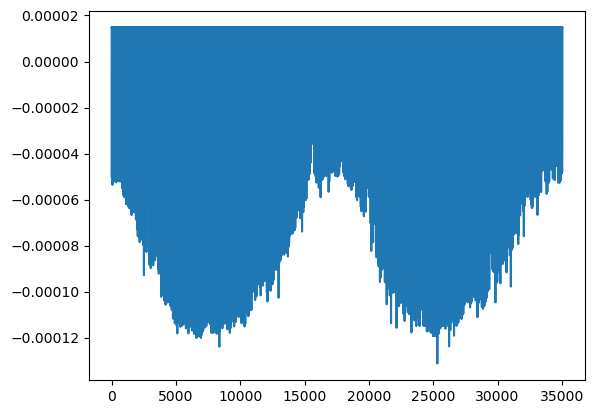

In [23]:
model_in = '1lin'
var_name = 'NEE'

# for i, site_name in enumerate(remain_sites):

site_name = 'ES-ES2'
print(site_name)
PLUMBER2_path_site = f"/srv/ccrc/LandAP/z5218916/script/PLUMBER2/LSM_GPP_PLUMBER2/nc_files/{site_name}.nc"
PLUMBER2_met_path  = "/srv/ccrc/LandAP/z5218916/data/Fluxnet_data/Post-processed_PLUMBER2_outputs/Nc_files/Met/"
PLUMBER2_flux_path = "/srv/ccrc/LandAP/z5218916/data/Fluxnet_data/Post-processed_PLUMBER2_outputs/Nc_files/Flux/"
file_path          = glob.glob(PLUMBER2_flux_path+"/*"+site_name+"*.nc")

with nc.Dataset(PLUMBER2_path_site, mode='r') as f:
    # try:
    if var_name == 'NEE':
        if model_in == 'NoahMPv401' or model_in == 'GFDL' or model_in == 'STEMMUS-SCOPE':
            var_tmp = f.variables[model_in + '_NEE'][:].data*(-1)
        else:
            var_tmp = f.variables[model_in + '_NEE'][:].data
    elif var_name == 'GPP':
        var_tmp = f.variables[model_in + '_GPP'][:].data

    print('var_tmp', np.sum(np.unique(var_tmp)))

    if model_in in models_calc_LAI:
        # print('in models_calc_LAI', model_in)
        LAI = read_LAI_model(site_name, model_in, model_LAI_names[model_in])
    else:
        # print('not in models_calc_LAI', model_in)
        LAI = read_LAI_obs(site_name, PLUMBER2_met_path)
    plt.plot(var_tmp)
    print('LAI', np.unique(LAI))

#         except:
#             print(model_in, site_name, 'not exists')
#             continue


<h5 style="color:orange;">Read LAI</h5>  

In [5]:
def read_LAI_obs(site_name, PLUMBER2_met_path):

    input_file     = glob.glob(PLUMBER2_met_path + site_name+"*.nc")[0]
    # print(input_file)
    f              = nc.Dataset(input_file, mode='r')
    LAI_obs        = f.variables['LAI'][:,0,0]
    LAI_obs        = np.where(LAI_obs==-9999., np.nan, LAI_obs)
    # print('LAI_obs',LAI_obs)

    return LAI_obs

def read_LAI_model(site_name, model_with_LAI, model_LAI_name):

    file_path      = glob.glob("/srv/ccrc/LandAP/z5218916/data/PLUMBER2/" + model_with_LAI +"/*"+site_name+"*.nc")
    if not file_path:
        LAI_model  = np.nan
    else:
        f              = nc.Dataset(file_path[0])
        LAI_model_tmp  = f.variables[model_LAI_name][:]
        veget          = None

        # Reset missing value
        for attr in ['_FillValue', '_fillValue', 'missing_value']:
            if hasattr(f.variables[model_LAI_name], attr):
                var_FillValue = getattr(f.variables[model_LAI_name], attr)
                LAI_model_tmp = np.where(LAI_model_tmp==var_FillValue, np.nan, LAI_model_tmp)
                break

        if hasattr(f.variables[model_LAI_name], 'dimensions'):
            if 'veget' in f.variables[model_LAI_name].dimensions:
                # print('model_name', model_name, 'site_name', site_name,'has veget demension' )
                veget = f.dimensions['veget'].size

        if veget is not None:
            if veget > 1:
                # if model uses patches
                # read veget fraction
                vegetfrac   = f.variables['vegetfrac']
                # print('model_name', model_name, 'site_name', site_name, 'veget = ', veget, 'vegetfrac =', vegetfrac )

                # initlize Var_tmp_tmp
                ntime     = len(LAI_model_tmp[:,0,0,0])
                LAI_model = np.zeros(ntime)

                # calculate the veget fraction weighted pixel value for each time step
                for i in np.arange(ntime):
                    for j in np.arange(0,veget):
                        LAI_model[i] = LAI_model[i] + LAI_model_tmp[i,j]*vegetfrac[i,j]
            else:
                # if patch == 1
                LAI_model = LAI_model_tmp.reshape(-1)
        else:
            # if model doesn't use patches
            LAI_model = LAI_model_tmp.reshape(-1)
        f.close()

    # print('LAI_model',LAI_model)

    return LAI_model

<h5 style="color:orange;">Calc annual mean</h5>  

In [6]:
def save_annual_mean(var_name, model_in, per_LAI=False):
    
    var       = np.zeros(170)
    Site_name = [""] * 170    # Creates a list with 170 empty strings
    lat       = np.zeros(170)
    lon       = np.zeros(170)
    
    for i, site_name in enumerate(remain_sites): 
        
        Site_name[i]       = site_name
        
        PLUMBER2_path_site = f"/srv/ccrc/LandAP/z5218916/script/PLUMBER2/LSM_GPP_PLUMBER2/nc_files/{site_name}.nc"
        PLUMBER2_met_path  = "/srv/ccrc/LandAP/z5218916/data/Fluxnet_data/Post-processed_PLUMBER2_outputs/Nc_files/Met/"
        PLUMBER2_flux_path = "/srv/ccrc/LandAP/z5218916/data/Fluxnet_data/Post-processed_PLUMBER2_outputs/Nc_files/Flux/"
        file_path          = glob.glob(PLUMBER2_flux_path+"/*"+site_name+"*.nc")
        
        with nc.Dataset(PLUMBER2_path_site, mode='r') as f:
            try:
                if var_name == 'NEE':
                    if model_in == 'NoahMPv401' or model_in == 'GFDL' or model_in == 'STEMMUS-SCOPE':
                        var_tmp = f.variables[model_in + '_NEE'][:].data*(-1)
                    else:
                        var_tmp = f.variables[model_in + '_NEE'][:].data
                elif var_name == 'GPP':
                    var_tmp = f.variables[model_in + '_GPP'][:].data
            except:
                print(model_in, site_name, 'not exists')
                continue
                
            if per_LAI:
                if model_in in models_calc_LAI:
                    # print('in models_calc_LAI', model_in)
                    LAI = read_LAI_model(site_name, model_in, model_LAI_names[model_in])
                else:
                    # print('not in models_calc_LAI', model_in)
                    LAI = read_LAI_obs(site_name, PLUMBER2_met_path)
                tmp = np.where(LAI == 0, np.nan, var_tmp/LAI)
                var[i] = np.nanmean(tmp)*365*24*3600
            else:
                var[i] = np.nanmean(var_tmp)*365*24*3600
                
                
        with nc.Dataset(file_path[0], mode='r') as f_flux:
            
            lat[i] = f_flux.variables['latitude'][0,0] 
            lon[i] = f_flux.variables['longitude'][0,0] 
            
#             if var_name == 'NEE':
#                 var_qc = f_flux.variables['NEE_qc'][:,0,0]
#             elif var_name == 'GPP':
#                 var_qc = f_flux.variables['GPP_qc'][:,0,0]
            
#             time   = nc.num2date(f_flux.variables['time'][:],f_flux.variables['time'].units,
#                                  only_use_cftime_datetimes=False,only_use_python_datetimes=True)

#             fig1 = plt.figure(figsize=(10, 5))
#             plot = plt.plot(time,var_qc)
#             plt.savefig(f'./plots/{var_name}_qc_obs_{site_name}.png',dpi=300)
    
    var_out              = pd.DataFrame(var, columns=[var_name])
    var_out['lat']       = lat
    var_out['lon']       = lon
    var_out['site_name'] = Site_name

    if per_LAI:
        var_out.to_csv(f'./txt/{var_name}_annual_mean_per_LAI_{model_in}.csv', index=False)
    else:
        var_out.to_csv(f'./txt/{var_name}_annual_mean_{model_in}.csv', index=False)
 

<h5 style="color:orange;">save annual mean parallally</h5>  

In [7]:
# Define a function to generate each plot
def save_annual_mean_parallal(var_name, per_LAI=False):
    
    PLUMBER2_path_site = "/srv/ccrc/LandAP/z5218916/script/PLUMBER2/LSM_GPP_PLUMBER2/nc_files/AU-How.nc"
    f                  = nc.Dataset(PLUMBER2_path_site, mode='r')
    model_list         = f.variables[f'{var_name}_models'][:]
    model_list         = model_list.tolist()
    model_list.append('obs')
    f.close()

    model_list = ['ORC2_r6593', 'ORC3_r8120']
    # Create a pool of workers (28 CPUs)
    with mp.Pool(processes=28) as pool:
        # Distribute the tasks across CPUs
        pool.starmap(save_annual_mean, [(var_name, model_in, per_LAI) for model_in in model_list])

In [ ]:
# var_name = 'NEE'
# per_LAI  = False
# save_annual_mean_parallal(var_name, per_LAI=per_LAI)

In [ ]:
var_name = 'NEE'
per_LAI  = True
save_annual_mean_parallal(var_name, per_LAI=per_LAI)

/jobfs/125063793.gadi-pbs/ipykernel_204063/1319111607.py:37: RuntimeWarning: invalid value encountered in divide
  tmp = np.where(LAI == 0, np.nan, var_tmp/LAI)


In [ ]:
var_name = 'GPP'
per_LAI  = False
save_annual_mean_parallal(var_name, per_LAI=per_LAI)

In [ ]:
var_name = 'GPP'
per_LAI  = True
save_annual_mean_parallal(var_name, per_LAI=per_LAI)

<h5 style="color:orange;">Plot save annual mean</h5>  

In [ ]:
def plot_annual_mean(var_name, model_in, per_LAI=False):
    if per_LAI:
        df = pd.read_csv(f'./txt/NEE_annual_mean_per_LAI_{model_in}.csv')
    else:
        df = pd.read_csv(f'./txt/NEE_annual_mean_{model_in}.csv')
    
    var = df[var_name]
    lat = df['lat']
    lon = df['lon']
    
    # Convert NEE to a numpy array (for easier manipulation)
    var = np.array(var)

    # Define the color map based on the sign of NEE
    colors = np.where(var > 0, 'red', 'blue')  # Blue for positive, red for negative
    colors = np.where(var == 0, 'gray', colors)  # Blue for positive, red for negative

    # Define marker size based on the absolute value of NEE (scaled for better visibility)
    marker_size = np.abs(var) * 100+20  # Adjust scaling factor (100) as necessary for your data

    # Create a global map plot
    fig = plt.figure(figsize=(10, 5))
    ax  = plt.axes(projection=ccrs.PlateCarree())

    plt.rcParams['text.usetex']     = False
    plt.rcParams['font.family']     = "sans-serif"
    plt.rcParams['font.serif']      = "Helvetica"
    plt.rcParams['axes.linewidth']  = 1.5
    plt.rcParams['axes.labelsize']  = 14
    plt.rcParams['font.size']       = 14
    plt.rcParams['legend.fontsize'] = 10
    plt.rcParams['xtick.labelsize'] = 14
    plt.rcParams['ytick.labelsize'] = 14

    almost_black = '#262626'
    # change the tick colors also to the almost black
    plt.rcParams['ytick.color']     = almost_black
    plt.rcParams['xtick.color']     = almost_black

    # change the text colors also to the almost black
    plt.rcParams['text.color']      = almost_black

    # Change the default axis colors from black to a slightly lighter black,
    # and a little thinner (0.5 instead of 1)
    plt.rcParams['axes.edgecolor']  = almost_black
    plt.rcParams['axes.labelcolor'] = almost_black

    # set the box type of sequence number
    props = dict(boxstyle="round", facecolor='white', alpha=0.0, ec='white')

    # Add coastlines and other map features
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':', color='gray')
    ax.add_feature(cfeature.LAND, facecolor='white')
    ax.add_feature(cfeature.OCEAN, facecolor="white") # edgecolor='none', 
    ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())  # [lon_min, lon_max, lat_min, lat_max]

    # Scatter plot the flux sites with colors and sizes based on NEE
    sc = ax.scatter(lon, lat, alpha= 0.7, c=colors, s=marker_size, edgecolor='none', transform=ccrs.PlateCarree()) # 

    # Set title and show the plot
    if per_LAI:
        plt.title(f'{model_in} {var_name} per LAI (Blue: -, C sink; Red: +, C source)')
        plt.savefig(f'./plots/Global_map_{var_name}_per_LAI_{model_in}.png',dpi=300)
    else:
        plt.title(f'{model_in} {var_name} (Blue: -, C sink; Red: +, C source)')
        plt.savefig(f'./plots/Global_map_{var_name}_{model_in}.png',dpi=300)

<h4 style="color:green;">Interannual variability NEE</h4>  

In [20]:
def plot_NEE_variance(model_in):

    nsite    = len(remain_sites)
    Variance = np.zeros(nsite)
    lat      = np.zeros(nsite)
    lon      = np.zeros(nsite)
    
    for s, site_name in enumerate(remain_sites[:]):

        PLUMBER2_path_site = f"/srv/ccrc/LandAP/z5218916/script/PLUMBER2/LSM_GPP_PLUMBER2/nc_files/{site_name}.nc"
        PLUMBER2_met_path  = "/srv/ccrc/LandAP/z5218916/data/Fluxnet_data/Post-processed_PLUMBER2_outputs/Nc_files/Flux/"
        file_path          = glob.glob(PLUMBER2_met_path+"/*"+site_name+"*.nc")

        with nc.Dataset(PLUMBER2_path_site, mode='r') as f:
            try:
                if model_in == 'NoahMPv401' or model_in == 'GFDL' or model_in == 'STEMMUS-SCOPE':
                    var = pd.DataFrame(f.variables[model_in + '_NEE'][:].data*(-1), columns=['NEE'])
                else:
                    var = pd.DataFrame(f.variables[model_in + '_NEE'][:].data, columns=['NEE']) 

                time       = nc.num2date(f.variables['CABLE_time'][:],f.variables['CABLE_time'].units,only_use_cftime_datetimes=False,only_use_python_datetimes=True)
                ntime      = len(time)
                year       = np.zeros(ntime)

                for i,t in enumerate(time):
                    year[i] = t.year

                var['year'] = year[:]

                var         = var.groupby(['year']).mean(numeric_only=True).reset_index()*365*24*3600

                if len(var) >=5:
                    Variance[s] = np.var(var['NEE'])
                    with nc.Dataset(file_path[0], mode='r') as f_flux:
                        lat[s] = f_flux.variables['latitude'][0,0] 
                        lon[s] = f_flux.variables['longitude'][0,0]
            except:
                print(model_in, site_name, 'not exists')
                continue

    # Convert NEE to a numpy array (for easier manipulation)
    Variance = np.array(Variance)

    # Define marker size based on the absolute value of NEE (scaled for better visibility)
    marker_size = np.abs(Variance) * 500  # Adjust scaling factor (100) as necessary for your data

    # Create a global map plot
    fig = plt.figure(figsize=(10, 5))
    ax  = plt.axes(projection=ccrs.PlateCarree())

    plt.rcParams['text.usetex']     = False
    plt.rcParams['font.family']     = "sans-serif"
    plt.rcParams['font.serif']      = "Helvetica"
    plt.rcParams['axes.linewidth']  = 1.5
    plt.rcParams['axes.labelsize']  = 14
    plt.rcParams['font.size']       = 14
    plt.rcParams['legend.fontsize'] = 10
    plt.rcParams['xtick.labelsize'] = 14
    plt.rcParams['ytick.labelsize'] = 14

    almost_black = '#262626'
    # change the tick colors also to the almost black
    plt.rcParams['ytick.color']     = almost_black
    plt.rcParams['xtick.color']     = almost_black

    # change the text colors also to the almost black
    plt.rcParams['text.color']      = almost_black

    # Change the default axis colors from black to a slightly lighter black,
    # and a little thinner (0.5 instead of 1)
    plt.rcParams['axes.edgecolor']  = almost_black
    plt.rcParams['axes.labelcolor'] = almost_black

    # set the box type of sequence number
    props = dict(boxstyle="round", facecolor='white', alpha=0.0, ec='white')

    # Add coastlines and other map features
    ax.coastlines()
    ax.add_feature(cfeature.BORDERS, linestyle=':', color='gray')
    ax.add_feature(cfeature.LAND, facecolor='white')
    ax.add_feature(cfeature.OCEAN, edgecolor='none', facecolor="white")
    ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())  # [lon_min, lon_max, lat_min, lat_max]

    # Scatter plot the flux sites with colors and sizes based on NEE
    sc = ax.scatter(lon, lat, alpha=0.7, c='blue', s=30, edgecolors='none', transform=ccrs.PlateCarree()) # marker_size

    # Set title and show the plot
    plt.title(f'{model_in} NEE Variance')

    plt.savefig(f'./plots/Global_map_NEE_Variance_{model_in}.png',dpi=300)

In [21]:
# Define a function to generate each plot
def plot_NEE_variance_parallal():
    
    PLUMBER2_path_site = "/srv/ccrc/LandAP/z5218916/script/PLUMBER2/LSM_GPP_PLUMBER2/nc_files/AU-How.nc"
    f                  = nc.Dataset(PLUMBER2_path_site, mode='r')
    model_list         = f.variables['NEE_models'][:]
    model_list         = model_list.tolist()
    model_list.append('obs')
    f.close()

    # Create a pool of workers (28 CPUs)
    with mp.Pool(processes=28) as pool:
        # Distribute the tasks across CPUs
        pool.map(plot_NEE_variance, model_list)  # Use map for single argument functions


In [22]:
plot_NEE_variance_parallal()

QUINCY US-Ha1 not exists


/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.07/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.07/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.07/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '
/g/data/hh5/public/apps/miniconda3/envs/analysis3-24.07/lib/python3.10/site-packages/cartopy/mpl/feature_artist.py:144: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn(

<h3 style="color:blue;">Seasonal NEE contribution to IAV</h3>  

<h4 style="color:green;">Monthly mean NEE</h4>  

In [ ]:
def save_monthly_mean(var_name, model_in, per_LAI=False):
    
    var       = np.zeros((12,170))
    Site_name = [""] * 170    # Creates a list with 170 empty strings
    lat       = np.zeros(170)
    lon       = np.zeros(170)
    
    for i, site_name in enumerate(remain_sites): 
        
        Site_name[i]       = site_name
        
        PLUMBER2_path_site = f"/srv/ccrc/LandAP/z5218916/script/PLUMBER2/LSM_GPP_PLUMBER2/nc_files/{site_name}.nc"
        PLUMBER2_met_path  = "/srv/ccrc/LandAP/z5218916/data/Fluxnet_data/Post-processed_PLUMBER2_outputs/Nc_files/Met/"
        PLUMBER2_flux_path = "/srv/ccrc/LandAP/z5218916/data/Fluxnet_data/Post-processed_PLUMBER2_outputs/Nc_files/Flux/"
        file_path          = glob.glob(PLUMBER2_flux_path+"/*"+site_name+"*.nc")
        
        with nc.Dataset(PLUMBER2_path_site, mode='r') as f:
            try:
                if var_name == 'NEE':
                    if model_in == 'NoahMPv401' or model_in == 'GFDL' or model_in == 'STEMMUS-SCOPE':
                        var_tmp = f.variables[model_in + '_NEE'][:].data*(-1)
                    else:
                        var_tmp = f.variables[model_in + '_NEE'][:].data
                elif var_name == 'GPP':
                    var_tmp = f.variables[model_in + '_GPP'][:].data

                time   = nc.num2date(f.variables['time'][:],f.variables['time'].units,
                                     only_use_cftime_datetimes=False,only_use_python_datetimes=True)
                
                month      = np.zeros(ntime)

                for tt,t in enumerate(time):
                    month[tt] = t.month
            except:
                print(model_in, site_name, 'not exists')
                continue
                
            if per_LAI:
                if model_in in models_calc_LAI:
                    # print('in models_calc_LAI', model_in)
                    LAI = read_LAI_model(site_name, model_in, model_LAI_names[model_in])
                else:
                    # print('not in models_calc_LAI', model_in)
                    LAI = read_LAI_obs(site_name, PLUMBER2_met_path)
                var_tmp = var_tmp/LAI
            else:
                var_tmp = var_tmp
        
            Var_tmp          = pd.DataFrame(var_tmp,columns=[var_name])
            Var_tmp['month'] = month
            var_t            = Var_tmp.groupby(['month']).mean(numeric_only=True)
            print(var_t)
            var[:,i]         = var_t[var_name].values
            print(var[:,i])
                
        with nc.Dataset(file_path[0], mode='r') as f_flux:
            
            lat[i] = f_flux.variables['latitude'][0,0] 
            lon[i] = f_flux.variables['longitude'][0,0] 

    for m in np.arange(1,13,1):
        var_out              = pd.DataFrame(var[m-1,:], columns=[var_name])
        var_out['lat']       = lat
        var_out['lon']       = lon
        var_out['site_name'] = Site_name

        if per_LAI:
            var_out.to_csv(f'./txt/{var_name}_month{m}_mean_per_LAI_{model_in}.csv', index=False)
        else:
            var_out.to_csv(f'./txt/{var_name}_month{m}_mean_{model_in}.csv', index=False)

In [ ]:
# Define a function to generate each plot
def save_monthly_mean_parallal(var_name, per_LAI=False):
    
    PLUMBER2_path_site = "/srv/ccrc/LandAP/z5218916/script/PLUMBER2/LSM_GPP_PLUMBER2/nc_files/AU-How.nc"
    f                  = nc.Dataset(PLUMBER2_path_site, mode='r')
    model_list         = f.variables[f'{var_name}_models'][:]
    model_list         = model_list.tolist()
    model_list.append('obs')
    f.close()

    # Create a pool of workers (28 CPUs)
    with mp.Pool(processes=28) as pool:
        # Distribute the tasks across CPUs
        pool.starmap(save_monthly_mean, [(var_name, model_in, per_LAI) for model_in in model_list])

In [9]:
len(model_list)

19

In [ ]:
var_name = 'NEE'
per_LAI  = False
save_monthly_mean_parallal(var_name, per_LAI=per_LAI)

In [ ]:
var_name = 'NEE'
per_LAI  = True
save_monthly_mean_parallal(var_name, per_LAI=per_LAI)

In [ ]:
var_name = 'GPP'
per_LAI  = False
save_monthly_mean_parallal(var_name, per_LAI=per_LAI)

In [ ]:
var_name = 'GPP'
per_LAI  = True
save_monthly_mean_parallal(var_name, per_LAI=per_LAI)

<h4 style="color:green;">Monthly NEE regression with annual NEE</h4>  

<h3 style="color:blue;">Modelled vs obsed NEE</h3>  

In [19]:
def plot_modelled_vs_observed(var_name,model_in, per_LAI):
    
    if per_LAI:
        df_obs   = pd.read_csv(f'./txt/{var_name}_annual_mean_per_LAI/{var_name}_annual_mean_per_LAI_obs.csv')
        df_model = pd.read_csv(f'./txt/{var_name}_annual_mean_per_LAI/{var_name}_annual_mean_per_LAI_{model_in}.csv')
    else:
        df_obs   = pd.read_csv(f'./txt/{var_name}_annual_mean/{var_name}_annual_mean_obs.csv')
        df_model = pd.read_csv(f'./txt/{var_name}_annual_mean/{var_name}_annual_mean_{model_in}.csv')
    
    print(df_obs)
    
    var_max = np.nanmax((df_model[var_name], df_obs[var_name]))
    var_min = np.nanmin((df_model[var_name], df_obs[var_name]))
    print(var_max,var_min)
    
    fig = plt.figure(figsize=(10, 10))
    ax  = plt.axes()
    
    # read site charaters
    df_char = pd.read_csv('./txt/site_character.csv')
    
    for site_name in site_names:
        mask_model = df_model['site_name'] == site_name
        mask_obs   = df_obs['site_name']   == site_name
        mask_char  = df_char['site_name']  == site_name
        
        obs        = df_obs.loc[mask_obs,'NEE'].values
        model      = df_model.loc[mask_model,'NEE'].values
        IGBP_type  = df_char.loc[mask_char,'IGBP'].values
        clim_type  = df_char.loc[mask_char,'clim_type'].values
        plot       = ax.scatter(obs, model,color=clim_colors[clim_type[0]])
        plot       = ax.plot(np.arange(var_min, var_max,(var_max-var_min)/100), np.arange(var_min, var_max,(var_max-var_min)/100),color='black')
        ax.set_xlim(-1000,2000)
        ax.set_ylim(-1000,2000)
        ax.legend()
    # ax.plot(np.linspace(var_min,var_max,100),np.linspace(var_min,var_max,100),color='black')
    plt.show()
    

             NEE        lat         lon site_name
0   -1994.169272 -33.464802  -66.459801    AR-SLu
1    -173.938805 -13.179040  130.794495    AU-Lit
2    3242.289859  55.683300   12.083300    DK-Lva
3     303.497878  39.323200  -86.413101    US-MMS
4     190.757268  38.413300 -120.950798    US-Var
..           ...        ...         ...       ...
165     0.000000   0.000000    0.000000       NaN
166     0.000000   0.000000    0.000000       NaN
167     0.000000   0.000000    0.000000       NaN
168     0.000000   0.000000    0.000000       NaN
169     0.000000   0.000000    0.000000       NaN

[170 rows x 4 columns]
4925.819823285565 -1994.1692717839032


/jobfs/125772066.gadi-pbs/ipykernel_3140015/2543959061.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


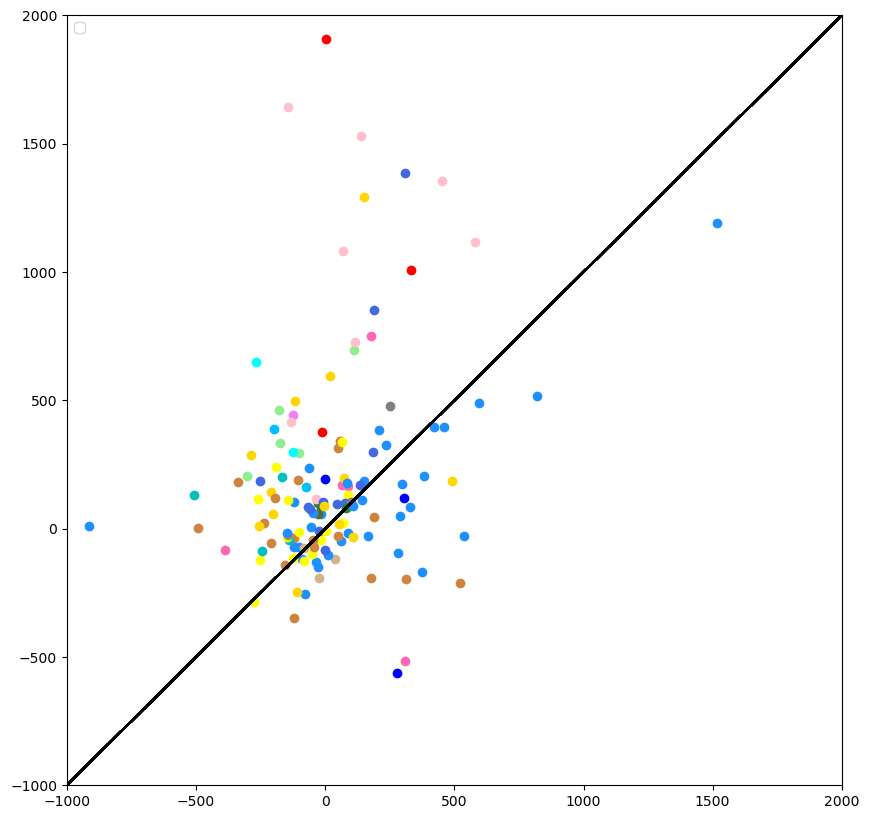

In [20]:
plot_modelled_vs_observed('NEE','CABLE', per_LAI=True)

<h3 style="color:blue;">Monthly values' Variance contribution rate: global map</h3>  

<h3 style="color:blue;">NEE interannual varibility: vegetation type bar map</h3>  

<h2 style="color:Black;">Divide canopy structure and physiology impact on NEE </h2>  

<h3 style="color:blue;">monthly->yearly: the hottest/coldest, wettest/driest 3 months in a year contribution to IAV</h3>  

<h3 style="color:blue;">hourly->daily: 3-hour peak contribution to daily NEE varibility</h3>